# Using ctapipe for PANOSETI

In [1]:
import panoseti_ctapipe_plugin

In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from panoseti_ctapipe_plugin import PanoEventSource
from ctapipe.visualization import ArrayDisplay, CameraDisplay

A few helper functions for visualization.

In [3]:
def as_datetime64_ns(ts):
    ts_array = np.asarray(ts)
    if np.issubdtype(ts_array.dtype, np.datetime64):
        return ts_array.astype("datetime64[ns]")
    return np.rint(ts_array.astype(np.float64) * 1e9).astype("int64").astype("datetime64[ns]")

def as_unix_seconds(ts):
    ts_array = np.asarray(ts)
    if np.issubdtype(ts_array.dtype, np.datetime64):
        return ts_array.astype("datetime64[ns]").astype("int64") * 1e-9
    return ts_array.astype(np.float64)

# Instrument

In [4]:
from panoseti_ctapipe_plugin import camera, geometry, optics, subarray

In [5]:
print(f"List of telescopes:\n{subarray.tel_ids}")
for tel_id in subarray.tel_ids:
    print(f"Telescope {tel_id}: {subarray.tel[tel_id].name}")

List of telescopes:
[1 2 3 4]
Telescope 1: Gattini
Telescope 2: Winter
Telescope 3: Fern
Telescope 4: PTI


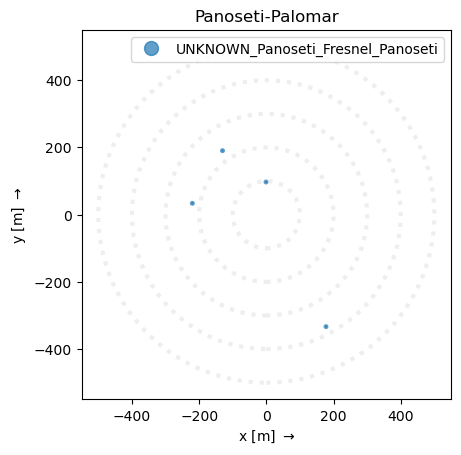

In [6]:
display = ArrayDisplay(subarray=subarray, tel_scale=8.0)

In [7]:
print(f"Telescope positions:\n{subarray.tel_coords}")

Telescope positions:
<SkyCoord (GroundFrame: reference_location=(-2410504.1281241677, -4758565.389341571, 3487983.3401647625) m): (x, y, z) in m
    [( 177.58, -333.33, 42.82), (-220.15,   33.67, 49.17),
     (-130.43,  190.4 , 34.66), (  -1.  ,   97.18, 39.7 )]>


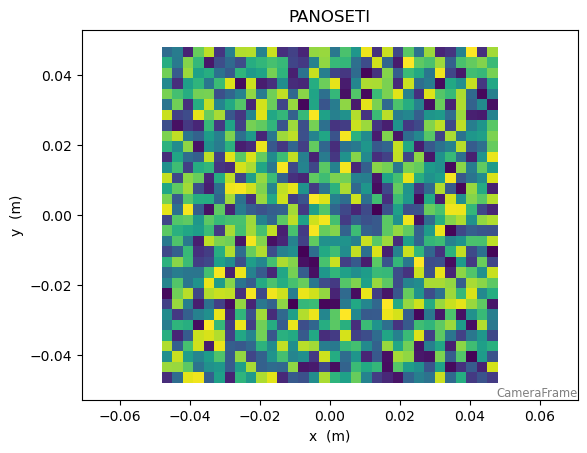

In [8]:
test_image = np.random.rand(1024)
display = CameraDisplay(geometry, cmap="viridis")
display.image = test_image
plt.show()

In [9]:
print(f"Telescope name: {subarray.tel[2].name}")
print(f"Telescope optics: {subarray.tel[2].optics}")
print(f"Telescope camera: {subarray.tel[2].camera}")

Telescope name: Winter
Telescope optics: Panoseti_Fresnel
Telescope camera: Panoseti


In [10]:
print(f"Telescope equivalent focal length: {subarray.tel[2].optics.equivalent_focal_length}")
print(f"Telescope mirror area: {subarray.tel[2].optics.mirror_area}")

Telescope equivalent focal length: 0.46 m
Telescope mirror area: 0.16619064 m2


In [11]:
print(f"Telescope camera number of pixels: {subarray.tel[2].camera.readout.n_pixels}")
print(f"Telescope camera pixel area: {subarray.tel[2].camera.geometry.pix_area}")

Telescope camera number of pixels: 1024
Telescope camera pixel area: [9.e-06 9.e-06 9.e-06 ... 9.e-06 9.e-06 9.e-06] m2


# Read data

Link to the pffd folder of the observation run.

In [12]:
path_pre = "/Users/ravikularaman/VScode-projects/panoseti-ctapipe-plugin/test_data/pff/obs_Palomar.start_2026-01-15T02:26:39Z.runtype_obs-test.pffd/obs_Palomar.start_2026-01-15T02:26:39Z.runtype_obs-test.pffd"
path_post = "/Users/ravikularaman/VSCode-projects/panoseti-ctapipe-plugin/test_data/pff/obs_Palomar.start_2026-01-15T05:54:39Z.runtype_obs-test.pffd/obs_Palomar.start_2026-01-15T05:54:39Z.runtype_obs-test.pffd"

In [13]:
print(PanoEventSource.is_compatible(path_pre))
print(PanoEventSource.is_compatible(path_post))

True
True


Among others, when creating an instance of ```PanoEventSource``` do not forget to specify 
- if chosen observation run is before or after meridian flip with the argument ```meridian_flip_phase``` which can be ```"pre"``` or ```"post"```
- which telescopes you are interested in using ```allowed_tels```(see tel ids in _instrument.py_).

In [14]:
source_pre = PanoEventSource(input_url=path_pre, max_events=100, meridian_flip_phase="pre", allowed_tels={2, 3, 4}, reference_tel_id=2, coincidence_time_window=0.001, show_progress=True)
source_post = PanoEventSource(input_url=path_post, max_events=100, meridian_flip_phase="post", allowed_tels={2, 3, 4}, reference_tel_id=2, coincidence_time_window=0.001, show_progress=True)

Example of the info stored in observation/scheduling blocks.

In [15]:
obs_blocks_1 = source_pre.observation_blocks
for obs_id, obs_block in obs_blocks_1.items():
    print(f"Observation Block ID: {obs_id}")
    print(f"Producer: {obs_block.producer_id}")
    print(f"Start Time: {obs_block.actual_start_time}")
    print(f"Pointing: {obs_block.subarray_pointing_lon}, {obs_block.subarray_pointing_lat}")
    print(f"Meridian flip: {obs_block.meta.get('meridian_flip')}")
print("-----------")
sched_blocks_1 = source_post.scheduling_blocks
for sched_id, sched_block in sched_blocks_1.items():
    print(f"Scheduling Block ID: {sched_id}")
    print(f"Producer: {sched_block.producer_id}")
    print(f"Scheduling type: {sched_block.sb_type}")
    print(f"Observing mode: {sched_block.observing_mode}")
    print(f"Pointing mode: {sched_block.pointing_mode}")

Observation Block ID: 0
Producer: Panoseti
Start Time: 2026-01-15T02:27:39.000
Pointing: 65.05425 deg, 90.0 deg
Meridian flip: pre
-----------
Scheduling Block ID: 20260115
Producer: Panoseti
Scheduling type: SchedulingBlockType.OBSERVATION
Observing mode: ObservingMode.ON_OFF
Pointing mode: PointingMode.TRACK


# Visualize raw data

In the following I use the post-meridian-flip data for illustration.

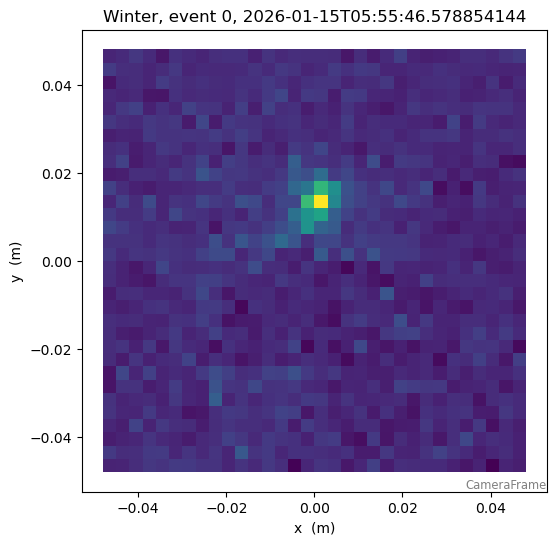

In [16]:
_, telescope_data, telescope_metadata = source_post.load_raw_telescope_streams()
telescope_timestamps = source_post.extract_telescope_timestamps(telescope_metadata)

tel_id = 2 # Winter
event_idx = 0
timestamp = as_datetime64_ns(telescope_timestamps[tel_id])[event_idx]
tel_name = subarray.tel[tel_id].name

raw_image = telescope_data[tel_id][event_idx].reshape(32, 32)

fig, ax = plt.subplots(figsize=(6, 6))
display = CameraDisplay(geometry, ax=ax, cmap="viridis")
display.image = raw_image.flatten()
ax.set_title(f"{tel_name}, event {event_idx}, {timestamp}")

plt.show()

# Gains

If no gain calibration data is given, this step takes an array filled with ones - so, no change.

In [17]:
gains = source_post.load_gains(verbose=True)
gain_corrected_telescope_data = source_post.apply_gain_corrections(telescope_data, gains)

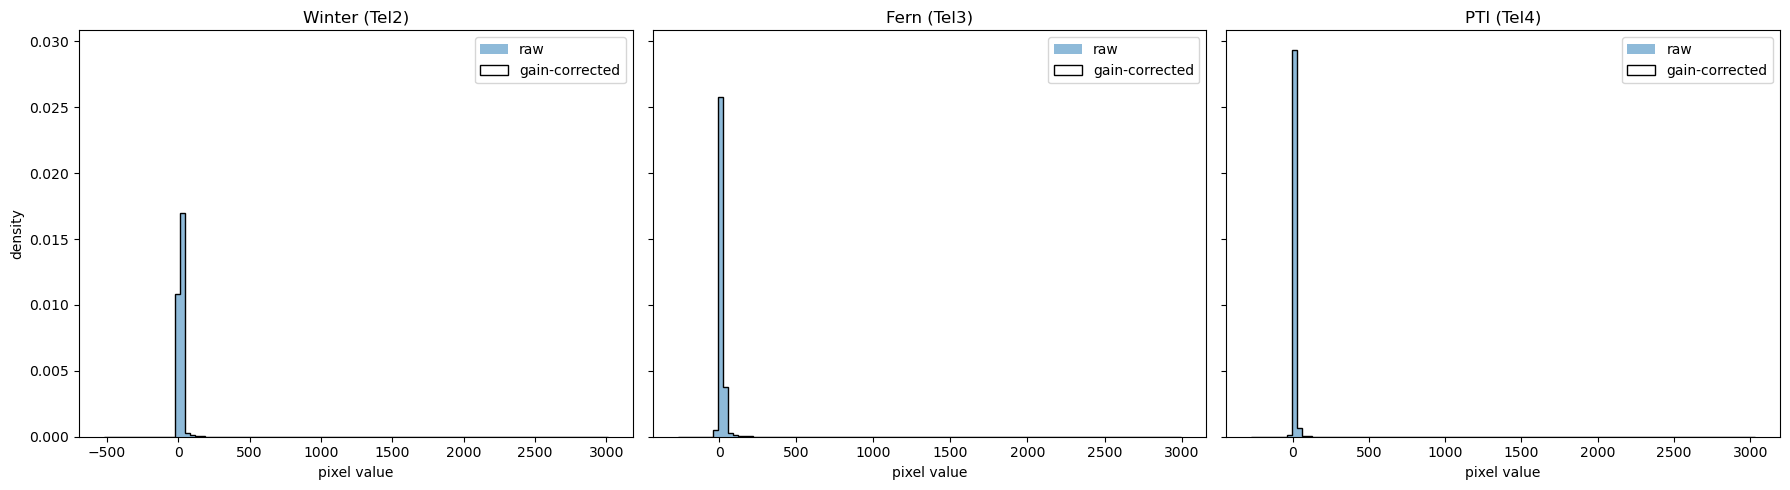

In [18]:
tel_ids = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tel_id in zip(axes, tel_ids):
    raw_pixels = telescope_data[tel_id].ravel()
    gaincorr_pixels = telescope_data[tel_id].ravel()
    tel_name = subarray.tel[tel_id].name

    ax.hist(raw_pixels, bins=100, alpha=0.5, density=True, label="raw")
    ax.hist(gaincorr_pixels, bins=100, histtype="step", color="black", density=True, label="gain-corrected")

    ax.set_title(f"{tel_name} (Tel{tel_id})")
    ax.set_xlabel("pixel value")
    ax.legend()

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

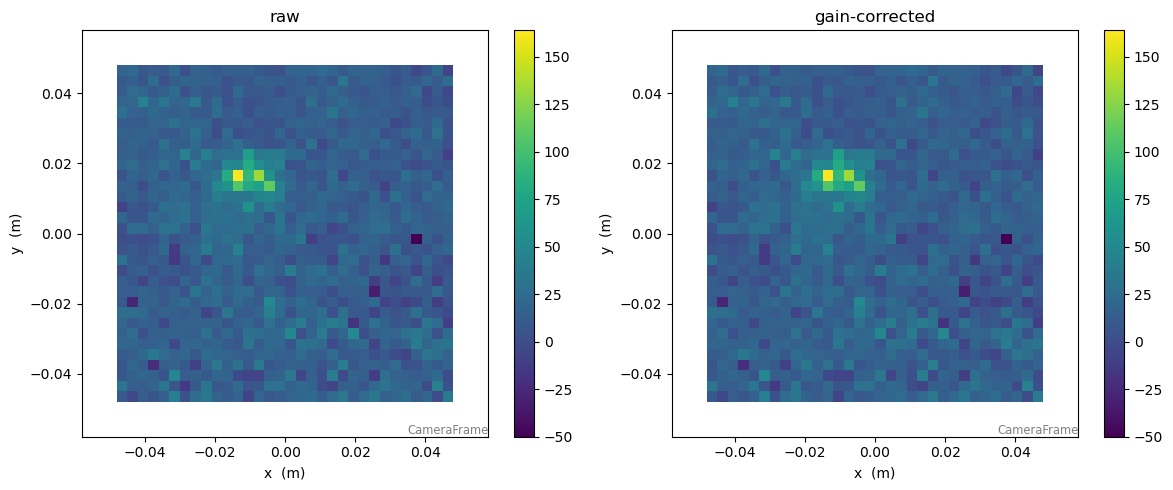

In [19]:
tel_id = 3
event_idx = 10

raw_image = telescope_data[tel_id][event_idx].reshape(32, 32)
gaincorr_image = telescope_data[tel_id][event_idx].reshape(32, 32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = CameraDisplay(geometry, ax=axes[0], cmap="viridis")
disp1.image = raw_image.flatten()
disp1.add_colorbar()
axes[0].set_title("raw")

disp2 = CameraDisplay(geometry, ax=axes[1], cmap="viridis")
disp2.image = gaincorr_image.flatten()
disp2.add_colorbar()
axes[1].set_title("gain-corrected")

plt.tight_layout()
plt.show()

# Filter data

Helper function to return stats after each filtering step.

In [20]:
def counts_by_tel(data_dict):
    return {tel_id: len(data) for tel_id, data in data_dict.items()}

initial_counts = counts_by_tel(telescope_data)
print('Initial counts by telescope:', initial_counts)

Initial counts by telescope: {2: 4356, 4: 5140, 3: 5724}


## Packet-loss filtering

In [21]:
packet_loss_filtered_telescope_data, packet_loss_filtered_telescope_timestamps, packet_loss_masks = source_post.apply_packet_loss_filters(gain_corrected_telescope_data, telescope_timestamps, telescope_metadata=telescope_metadata, verbose=True)

packet_loss_filtered_telescope_metadata = source_post.apply_metadata_masks(telescope_metadata, packet_loss_masks)

packet_loss_counts = counts_by_tel(packet_loss_filtered_telescope_data)
print('Counts by telescope after packet loss filtering:', packet_loss_counts)    
print('Number of events filtered out by packet loss filter:', initial_counts[2] - packet_loss_counts[2], 'for telescope 2')
print('Number of events filtered out by packet loss filter:', initial_counts[3] - packet_loss_counts[3], 'for telescope 3')
print('Number of events filtered out by packet loss filter:', initial_counts[4] - packet_loss_counts[4], 'for telescope 4')                                                

Counts by telescope after packet loss filtering: {2: 4356, 4: 5140, 3: 5724}
Number of events filtered out by packet loss filter: 0 for telescope 2
Number of events filtered out by packet loss filter: 0 for telescope 3
Number of events filtered out by packet loss filter: 0 for telescope 4


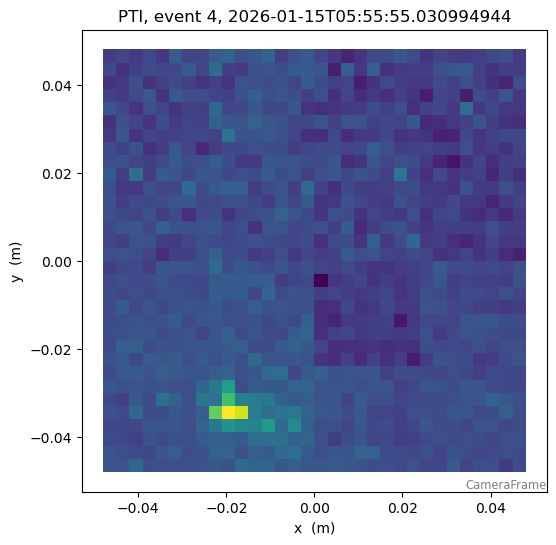

In [22]:
tel_id = 4
event_idx = 4
timestamp = as_datetime64_ns(packet_loss_filtered_telescope_timestamps[tel_id])[event_idx]
tel_name = subarray.tel[tel_id].name

raw_image = telescope_data[tel_id][event_idx].reshape(32, 32)

fig, ax = plt.subplots(figsize=(6, 6))
display = CameraDisplay(geometry, ax=ax, cmap="viridis")
display.image = raw_image.flatten()
ax.set_title(f"{tel_name}, event {event_idx}, {timestamp}")

plt.show()

## Rate-spike filtering

In [23]:
rate_spike_filtered_telescope_data, rate_spike_filtered_telescope_timestamps, rate_spike_masks = source_post.apply_rate_spike_filters(packet_loss_filtered_telescope_data, packet_loss_filtered_telescope_timestamps, verbose=True)

rate_spike_filtered_telescope_metadata = source_post.apply_metadata_masks(packet_loss_filtered_telescope_metadata, rate_spike_masks)
rate_spike_counts = counts_by_tel(rate_spike_filtered_telescope_data)
print('Counts by telescope after rate spike filtering:', rate_spike_counts)   

print('Number of events filtered out by rate spike filter:', packet_loss_counts[2] - rate_spike_counts[2], 'for telescope 2')
print('Number of events filtered out by rate spike filter:', packet_loss_counts[3] - rate_spike_counts[3], 'for telescope 3')
print('Number of events filtered out by rate spike filter:', packet_loss_counts[4] - rate_spike_counts[4], 'for telescope 4')

Counts by telescope after rate spike filtering: {2: 4356, 4: 5140, 3: 5724}
Number of events filtered out by rate spike filter: 0 for telescope 2
Number of events filtered out by rate spike filter: 0 for telescope 3
Number of events filtered out by rate spike filter: 0 for telescope 4


## Invalid-timestamp filtering

In [24]:
valid_timestamp_filtered_telescope_data, valid_timestamp_filtered_telescope_timestamps, valid_timestamp_masks = source_post.apply_invalid_timestamp_filters(rate_spike_filtered_telescope_data, rate_spike_filtered_telescope_timestamps, verbose=True)

valid_timestamp_filtered_telescope_metadata = source_post.apply_metadata_masks(rate_spike_filtered_telescope_metadata, valid_timestamp_masks)
timestamp_counts = counts_by_tel(valid_timestamp_filtered_telescope_data)
print('Counts by telescope after invalid timestamp filtering:', timestamp_counts)   
print('Number of events filtered out by invalid timestamp filter:', rate_spike_counts[2] - timestamp_counts[2], 'for telescope 2')
print('Number of events filtered out by invalid timestamp filter:', rate_spike_counts[3] - timestamp_counts[3], 'for telescope 3')
print('Number of events filtered out by invalid timestamp filter:', rate_spike_counts[4] - timestamp_counts[4], 'for telescope 4')

Counts by telescope after invalid timestamp filtering: {2: 4356, 4: 5140, 3: 5724}
Number of events filtered out by invalid timestamp filter: 0 for telescope 2
Number of events filtered out by invalid timestamp filter: 0 for telescope 3
Number of events filtered out by invalid timestamp filter: 0 for telescope 4


# Pedestals/Pedvars

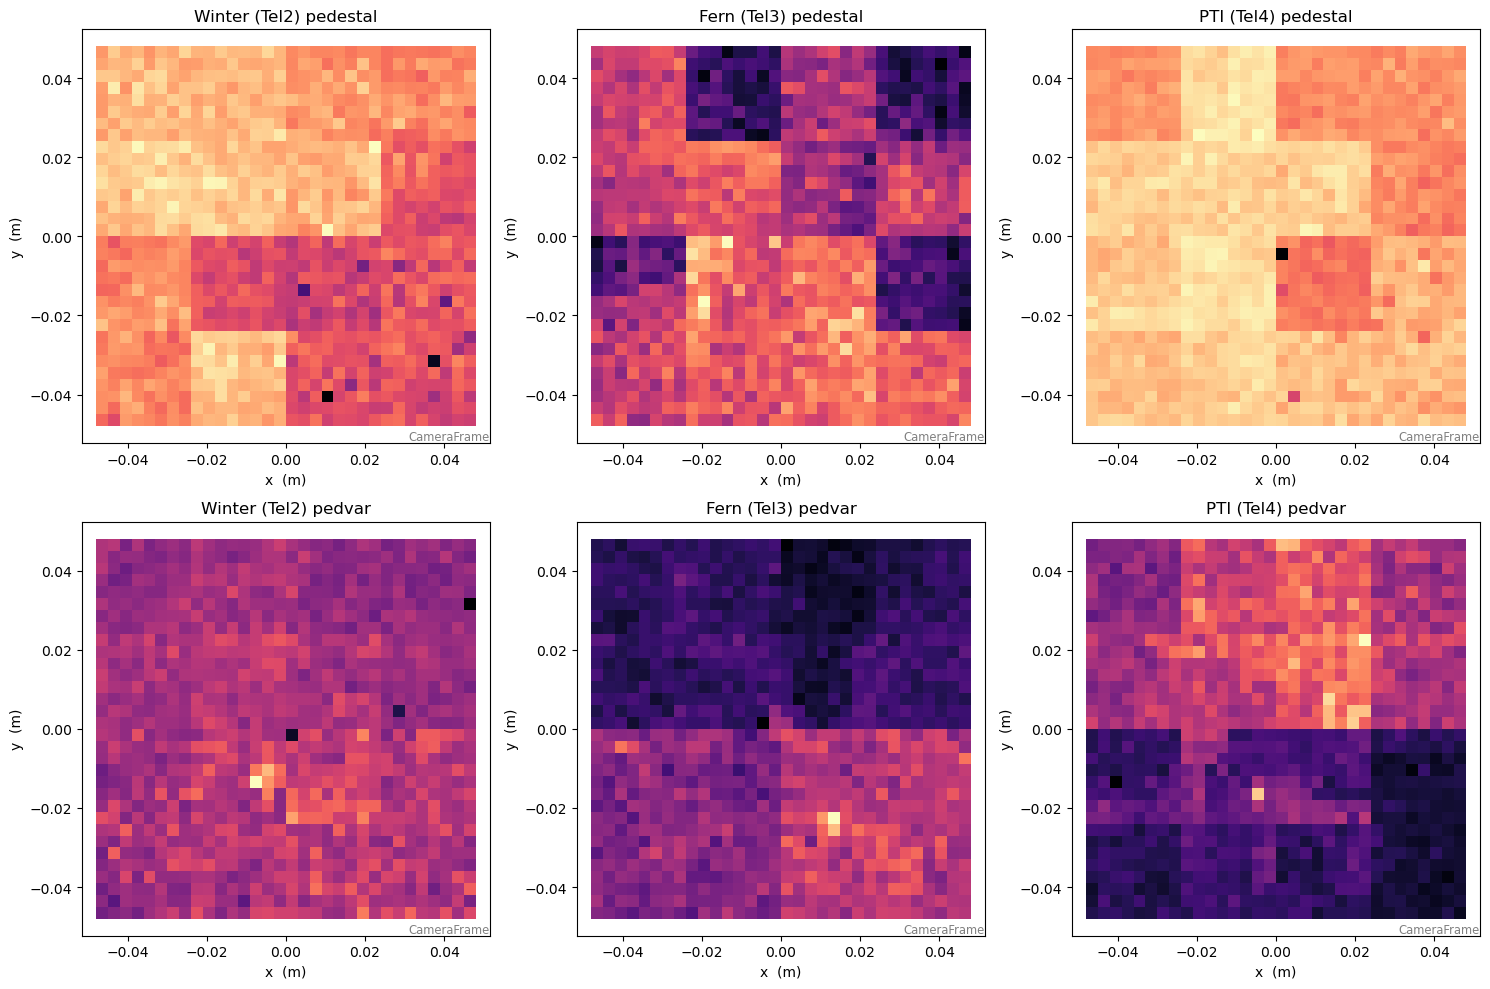

In [25]:
pedestals, pedvars = source_post.compute_pedestal_pedvar(
    all_data=valid_timestamp_filtered_telescope_data,
    nsig=5.0,
    verbose=True,
)

tel_ids = [2, 3, 4]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, tel_id in enumerate(tel_ids):
    tel_name = subarray.tel[tel_id].name

    display_ped = CameraDisplay(geometry, ax=axes[0, col], cmap="magma")
    display_ped.image = pedestals[tel_id].flatten()
    axes[0, col].set_title(f"{tel_name} (Tel{tel_id}) pedestal")

    display_var = CameraDisplay(geometry, ax=axes[1, col], cmap="magma")
    display_var.image = pedvars[tel_id].flatten()
    axes[1, col].set_title(f"{tel_name} (Tel{tel_id}) pedvar")

plt.tight_layout()
plt.show()

## Pedestal subtraction

In [26]:
pedestal_subtracted_telescope_data = source_post.apply_pedestal_subtraction(valid_timestamp_filtered_telescope_data, pedestals)

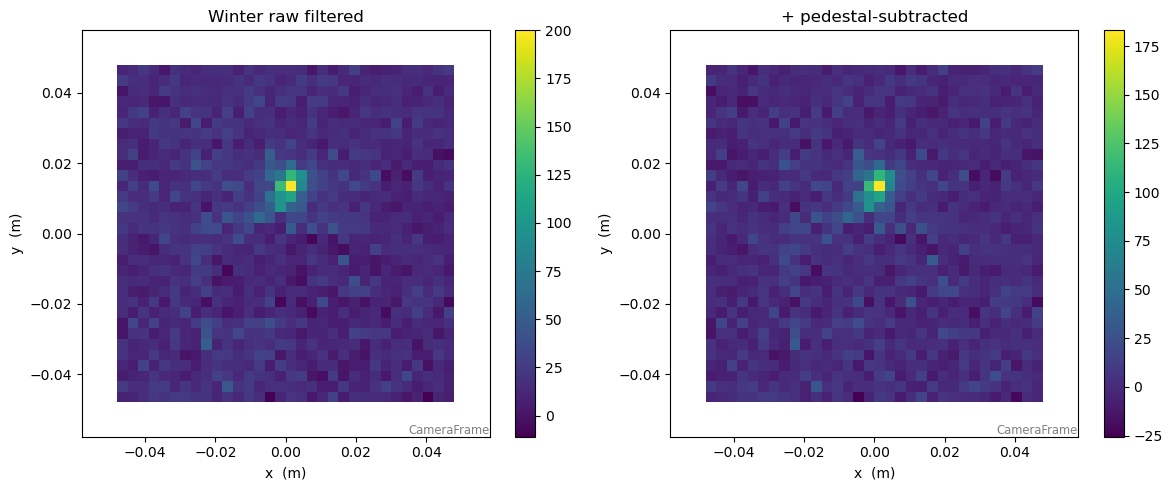

In [27]:
tel_id = 2
event_idx = 0

raw_image = valid_timestamp_filtered_telescope_data[tel_id][event_idx].reshape(32, 32)
pedsub_image = pedestal_subtracted_telescope_data[tel_id][event_idx].reshape(32, 32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

display_raw = CameraDisplay(geometry, ax=axes[0], cmap="viridis")
display_raw.image = raw_image.flatten()
display_raw.add_colorbar()
axes[0].set_title(f"{subarray.tel[tel_id].name} raw filtered")

display_pedsub = CameraDisplay(geometry, ax=axes[1], cmap="viridis")
display_pedsub.image = pedsub_image.flatten()
display_pedsub.add_colorbar()
axes[1].set_title(f"+ pedestal-subtracted")

plt.tight_layout()
plt.show()

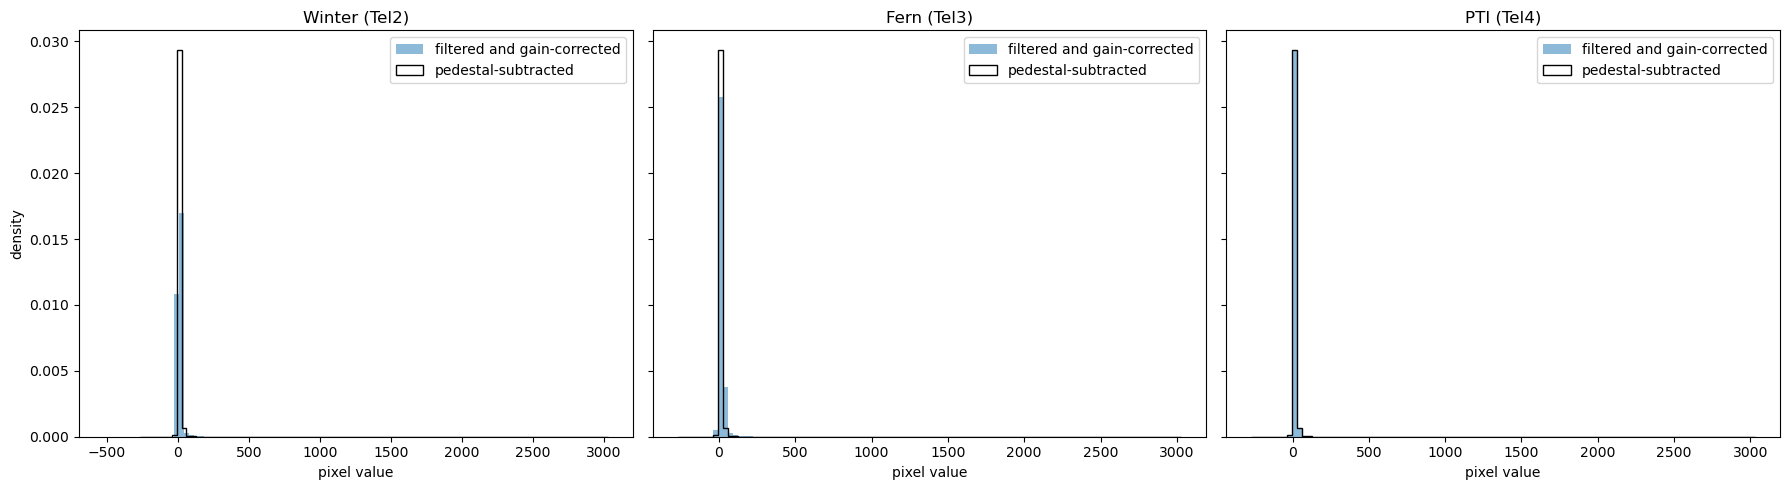

In [28]:
tel_ids = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tel_id in zip(axes, tel_ids):
    raw_pixels = valid_timestamp_filtered_telescope_data[tel_id].ravel()
    pedsub_pixels = pedestal_subtracted_telescope_data[tel_id].ravel()
    tel_name = subarray.tel[tel_id].name

    ax.hist(raw_pixels, bins=100, alpha=0.5, density=True, label="filtered and gain-corrected")
    ax.hist(gaincorr_pixels, bins=100, histtype="step", color="black", density=True, label="pedestal-subtracted")

    ax.set_title(f"{tel_name} (Tel{tel_id})")
    ax.set_xlabel("pixel value")
    ax.legend()

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

# Meridian flip 

In [29]:
meridian_flip_corrected_telescope_data = source_post.apply_meridian_flip_corrections(pedestal_subtracted_telescope_data)

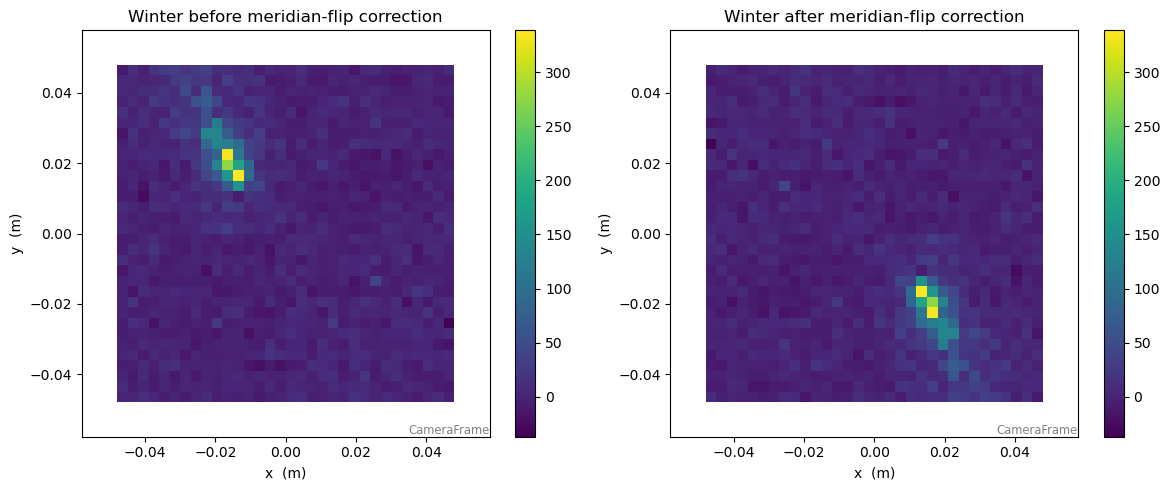

In [30]:
tel_id = 2
event_idx = 203

before_flip = pedestal_subtracted_telescope_data[tel_id][event_idx].reshape(32, 32)
after_flip = meridian_flip_corrected_telescope_data[tel_id][event_idx].reshape(32, 32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = CameraDisplay(geometry, ax=axes[0], cmap="viridis")
disp1.image = before_flip.flatten()
disp1.add_colorbar()
axes[0].set_title(f"{subarray.tel[tel_id].name} before meridian-flip correction")

disp2 = CameraDisplay(geometry, ax=axes[1], cmap="viridis")
disp2.image = after_flip.flatten()
disp2.add_colorbar()
axes[1].set_title(f"{subarray.tel[tel_id].name} after meridian-flip correction")

plt.tight_layout()
plt.show()

# Timing correction

Added sorting step before and after timing correction, but doesn't seem necessary.

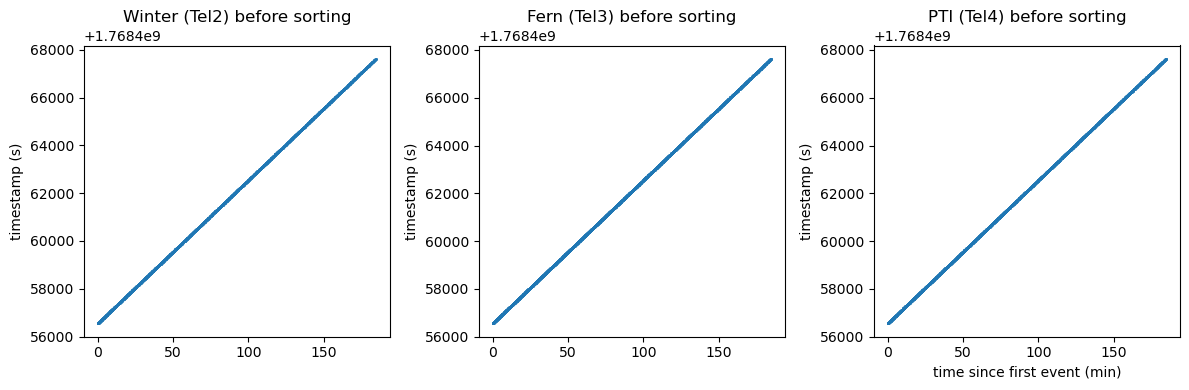

In [31]:
tel_ids = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=True)

for ax, tel_id in zip(axes, tel_ids):
    ts_seconds = as_unix_seconds(valid_timestamp_filtered_telescope_timestamps[tel_id])
    t_rel_min = (ts_seconds - ts_seconds.min()) / 60.0

    ax.plot(t_rel_min, ts_seconds, ".", markersize=2, alpha=0.5)
    ax.set_title(f"{subarray.tel[tel_id].name} (Tel{tel_id}) before sorting")
    ax.set_ylabel("timestamp (s)")

axes[-1].set_xlabel("time since first event (min)")
plt.tight_layout()
plt.show()

In [32]:
sorted_telescope_data, sorted_telescope_timestamps, sort_indices_by_tel = source_post.apply_telescope_stream_sorting(
    meridian_flip_corrected_telescope_data, valid_timestamp_filtered_telescope_timestamps, verbose=True)

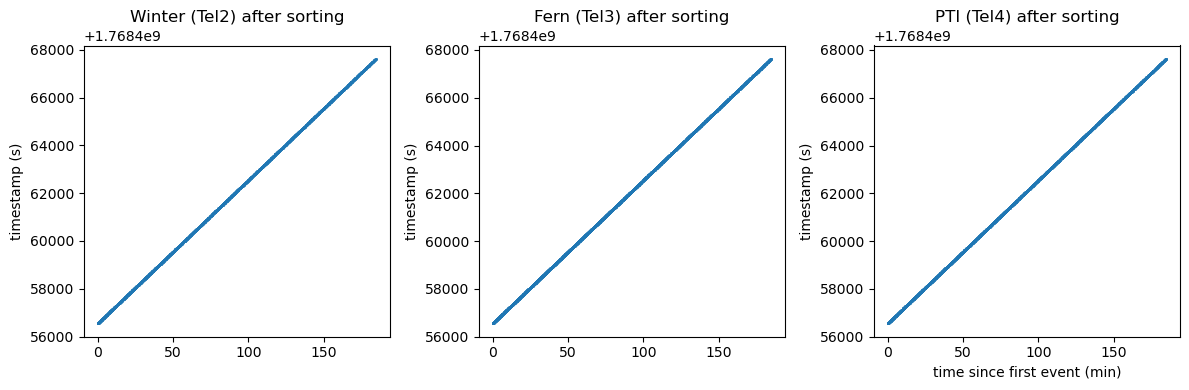

In [33]:
tel_ids = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

for ax, tel_id in zip(axes, tel_ids):
    ts_seconds = as_unix_seconds(sorted_telescope_timestamps[tel_id])
    t_rel_min = (ts_seconds - ts_seconds.min()) / 60.0

    ax.plot(t_rel_min, ts_seconds, ".", markersize=2, alpha=0.5)
    ax.set_title(f"{subarray.tel[tel_id].name} (Tel{tel_id}) after sorting")
    ax.set_ylabel("timestamp (s)")

axes[-1].set_xlabel("time since first event (min)")
plt.tight_layout()
plt.show()

## Timing offsets

In [34]:
from panoseti_ctapipe_plugin.plugin_src.functions import measure_telescope_timing_offset

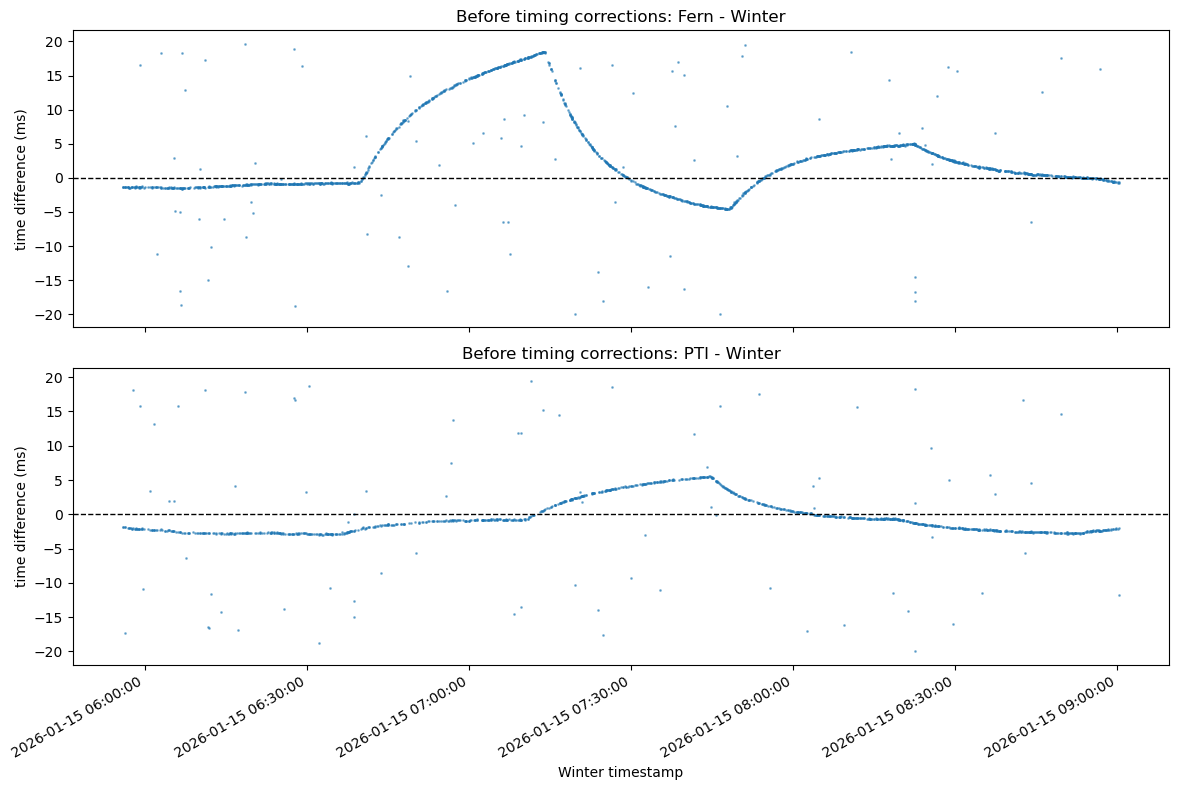

In [35]:
import matplotlib.dates as mdates

pairs = [(3, 2, "Fern - Winter"), (4, 2, "PTI - Winter")]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, (tel_id, ref_id, label) in zip(axes, pairs):
    _, winter_time_coinc, dt = measure_telescope_timing_offset(
        sorted_telescope_timestamps[tel_id],
        sorted_telescope_timestamps[ref_id],
        window=0.02,
    )

    winter_time_py = as_datetime64_ns(winter_time_coinc).astype("datetime64[ms]").tolist()
    dt_ms = dt * 1000.0

    ax.plot(winter_time_py, dt_ms, ".", markersize=2, alpha=0.5)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"Before timing corrections: {label}")
    ax.set_ylabel("time difference (ms)")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

axes[-1].set_xlabel("Winter timestamp")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [38]:
corrected_telescope_timestamps, timing_results = source_post.apply_timing_corrections(sorted_telescope_timestamps, reference_tel_id=2, window=0.02, bin_width=120, verbose=True)

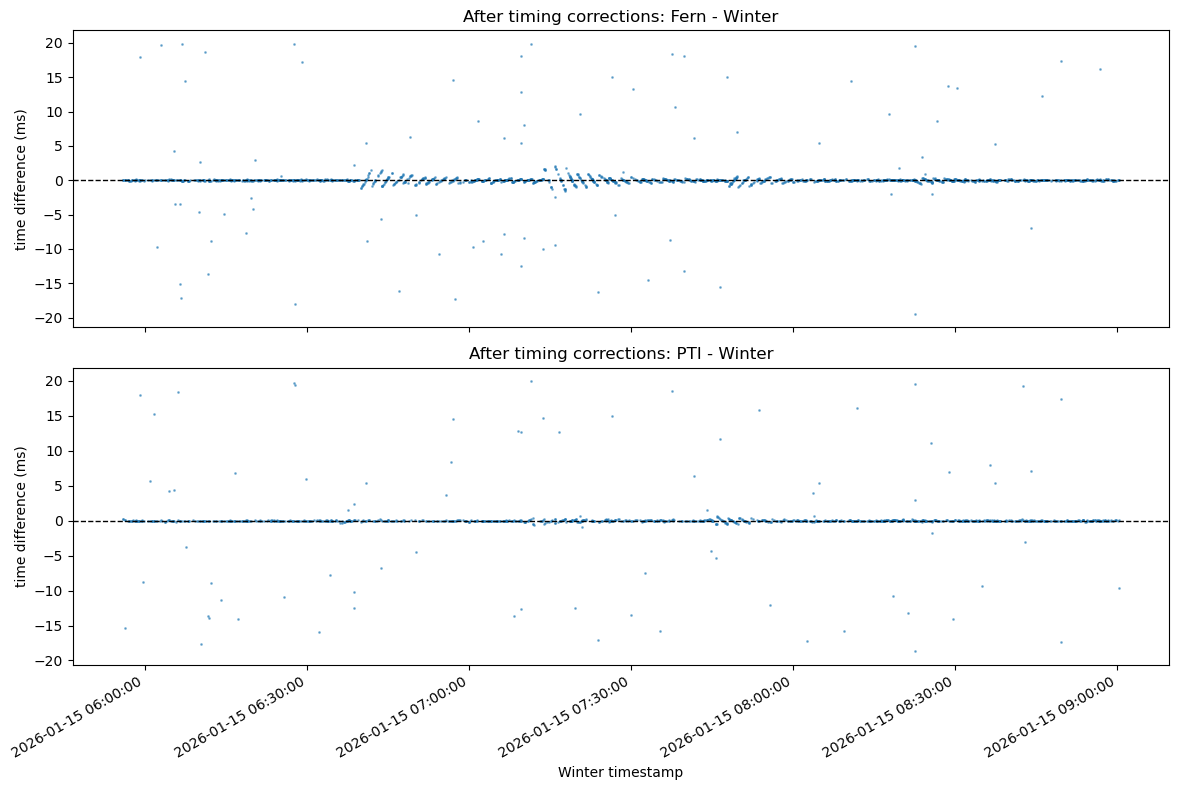

In [39]:
import matplotlib.dates as mdates

pairs = [(3, 2, "Fern - Winter"), (4, 2, "PTI - Winter")]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, (tel_id, ref_id, label) in zip(axes, pairs):
    _, winter_time_coinc, dt = measure_telescope_timing_offset(
        corrected_telescope_timestamps[tel_id],
        corrected_telescope_timestamps[ref_id],
        window=0.02,
    )

    winter_time_py = as_datetime64_ns(winter_time_coinc).astype("datetime64[ms]").tolist()
    dt_ms = dt * 1000.0

    ax.plot(winter_time_py, dt_ms, ".", markersize=2, alpha=0.5)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"After timing corrections: {label}")
    ax.set_ylabel("time difference (ms)")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

axes[-1].set_xlabel("Winter timestamp")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

...some artefacts that did not appear in pre-flip files...

In [40]:
sorted_after_corr_data, sorted_after_corr_timestamps, sort_indices_after_corr = source_post.apply_telescope_stream_sorting(
    meridian_flip_corrected_telescope_data,
    corrected_telescope_timestamps,
    verbose=True,
)

# Coincidence-matching

In [41]:
coincidences = source_post.apply_coincidence_matching(
    sorted_after_corr_data,
    sorted_after_corr_timestamps,
    time_window=0.001,
    verbose=True,
)

In [42]:
len(coincidences)

2540

In [43]:
tel_id_set_counts = {}
for coinc in coincidences:
    tel_id_set = tuple(coinc["tel_ids"])
    tel_id_set_counts[tel_id_set] = tel_id_set_counts.get(tel_id_set, 0) + 1

sorted(tel_id_set_counts.items())

[((2, 3), 1669), ((2, 3, 4), 871)]

# _generator()

### All of the above steps can be executed in a single line:

In [44]:
with PanoEventSource(
    input_url=path_pre,
    max_events=20,
    meridian_flip_phase="pre",
    allowed_tels={2, 3, 4},
    reference_tel_id=2,
    coincidence_time_window=0.001,
    show_progress=True,
) as source:
    for event in source:
        •••

SyntaxError: invalid character '•' (U+2022) (2360208172.py, line 11)

# Image cleaning

In [45]:
from ctapipe.image import tailcuts_clean
import numpy as np

images_by_event = {}

with PanoEventSource(
    input_url=path_pre,
    max_events=20,
    meridian_flip_phase="pre",
    allowed_tels={2, 3, 4},
    reference_tel_id=2,
    coincidence_time_window=0.001,
) as source:
    for event in source:
        event_id = event.count
        images_by_event[event_id] = {}

        for tel_id in event.trigger.tels_with_trigger:
            image = event.dl1.tel[tel_id].image

            clean_mask = tailcuts_clean(
                geometry,
                image,
                picture_thresh=10.0,
                boundary_thresh=5.0,
            )

            images_by_event[event_id][tel_id] = {
                "raw": image,
                "cleaned": np.where(clean_mask, image, 0.0),
            }

Found 4 events with invalid timestamps (before 2000-01-01)
Found 7 events with invalid timestamps (before 2000-01-01)
Found 1 events with invalid timestamps (before 2000-01-01)


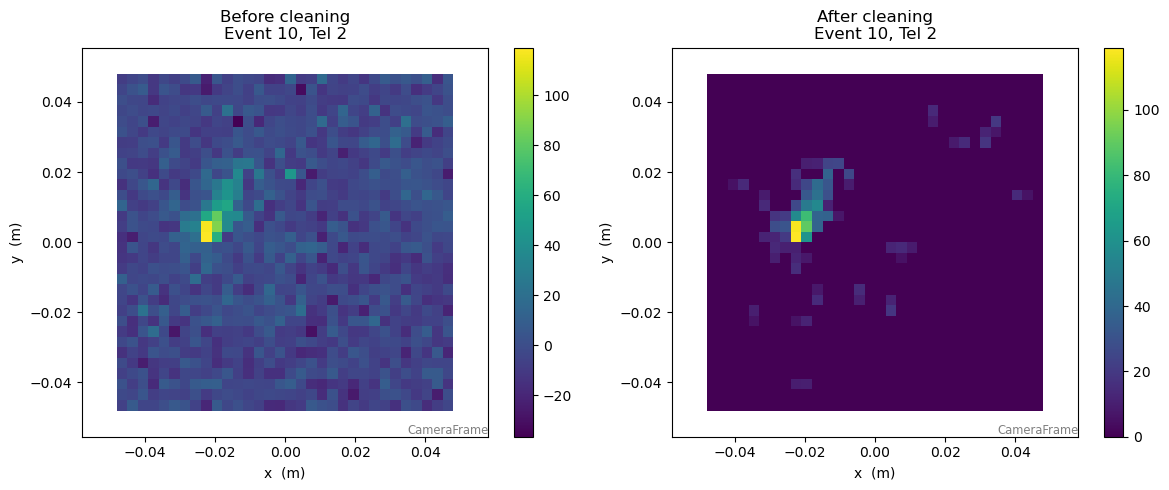

In [46]:
event_id = 10
tel_id = 2

raw_image = images_by_event[event_id][tel_id]["raw"]
cleaned_image = images_by_event[event_id][tel_id]["cleaned"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_raw = CameraDisplay(geometry, ax=axes[0], cmap="viridis")
disp_raw.image = raw_image
disp_raw.add_colorbar()
axes[0].set_title(f"Before cleaning\nEvent {event_id}, Tel {tel_id}")

disp_clean = CameraDisplay(geometry, ax=axes[1], cmap="viridis")
disp_clean.image = cleaned_image
disp_clean.add_colorbar()
axes[1].set_title(f"After cleaning\nEvent {event_id}, Tel {tel_id}")

plt.tight_layout()
plt.show()

# Hillas parameterization

In [47]:
from ctapipe.image import tailcuts_clean, hillas_parameters
import numpy as np

hillas_by_event = {}

with PanoEventSource(
    input_url=path_pre,
    max_events=20,
    meridian_flip_phase="pre",
    allowed_tels={2, 3, 4},
    reference_tel_id=2,
    coincidence_time_window=0.001,
) as source:
    for event in source:
        event_id = event.count
        hillas_by_event[event_id] = {}

        for tel_id in event.trigger.tels_with_trigger:
            image = event.dl1.tel[tel_id].image

            clean_mask = tailcuts_clean(
                geometry,
                image,
                picture_thresh=10.0,
                boundary_thresh=5.0,
            )

            if clean_mask.sum() < 3:
                continue

            hillas = hillas_parameters(
                geometry[clean_mask],
                image[clean_mask],
            )

            hillas_by_event[event_id][tel_id] = hillas

Found 4 events with invalid timestamps (before 2000-01-01)
Found 7 events with invalid timestamps (before 2000-01-01)
Found 1 events with invalid timestamps (before 2000-01-01)


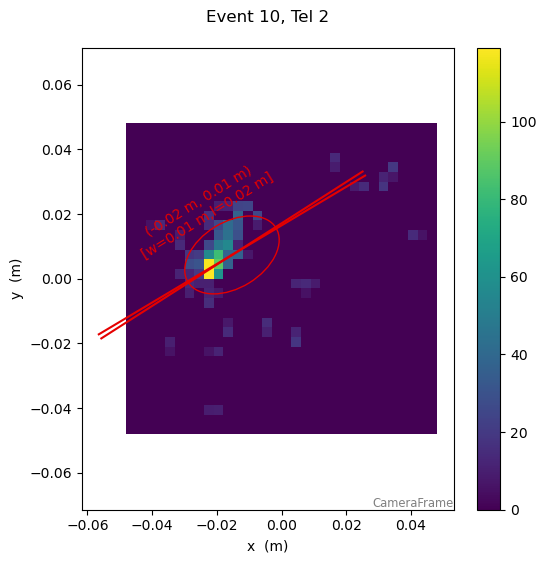

In [49]:
event_id = 10
tel_id = 2

cleaned_image = images_by_event[event_id][tel_id]["cleaned"]
hillas = hillas_by_event[event_id][tel_id]

fig, ax = plt.subplots(figsize=(6, 6))
disp = CameraDisplay(geometry, ax=ax, cmap="viridis")
cleaned = cleaned_image.copy()
#cleaned[~clean_mask] = 0.0
disp.image = cleaned
disp.add_colorbar()
disp.overlay_moments(hillas, color="xkcd:red")
ax.set_title(
    f"Event {event_id}, Tel {tel_id}\n"
)
plt.show()